#Mini-project 2
##Customer Segmentation
###Weeks 4 and 5

In today's business landscape, customer satisfaction is paramount. However, it's important to acknowledge that it's impossible to please everyone, and this is a reality that must be accepted. It's crucial to recognize this early on, as it will serve you and your business well. 

That's why business analysts typically start by segmenting customers (both current and potential) into groups based on their needs, wants, and shared characteristics. By understanding the preferences of your customers, you can develop tailored strategies to attract them and provide them with the best possible products and services. 

There are various methods for segmenting customers, including hierarchical clustering, Recency Frequency & Monetary (RFM) segmentation, and K-means clustering, among others.

In this notebook, you will be dealing with transactional and customer datasets to do customer segmentation on different levels.

The challenge for the busineses that we will be dealing with in this notebook is to divide their customers into groups based on both their personalities (demographics) and their spending behaviors. This approach can offer valuable insights into the characteristics and habits of their customer base.

We will be utilizing a variety of tools and libraries, including:

* Pandas for importing and manipulating data in a dataframe format
* Numpy and Scipy for performing essential mathematical calculations
* Scikit-Learn for constructing our Customer Segmentation Model
* Seaborn, Matplotlib, and Plotly Express for creating compelling visualizations of our data.

In [1]:
#Imports
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_theme(style='whitegrid')


In [2]:
#Read the dataset attached with this mini-project
#Dataset1_customer_segmentation
df = pd.read_csv('Dataset1_customer_segment.csv')
print(df.shape)


(2240, 10)


In [3]:
#of course run .head() to check the first 5 rows in the data
df.head()


,ID,Year_Birth,Education,Marital_Status,Income,TotalAmountSpent,Kidhome,Teenhome,Dt_Customer,Recency
0,5524,1957,Graduation,Single,58138.0,1617,0,0,4/9/12,58
1,2174,1954,Graduation,Single,46344.0,27,1,1,8/3/14,38
2,4141,1965,Graduation,Together,71613.0,776,0,0,21-08-2013,26
3,6182,1984,Graduation,Together,26646.0,53,1,0,10/2/14,26
4,5324,1981,PhD,Married,58293.0,422,1,0,19-01-2014,94


The dataset has the following features:

* DtCustomer - date of customer’s enrolment with the company
* Education - customer’s level of education
* Marital - customer’s marital status
* Kidhome - number of small children in customer’s household
* Teenhome - number of teenagers in customer’s household
* Income - customer’s yearly household income
* Recency - number of days since the last purchase
* TotalAmountSpent

In [4]:
#use .describe() to know more about your data
df.describe()


,ID,Year_Birth,Income,TotalAmountSpent,Kidhome,Teenhome,Recency
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,605.798214,0.444196,0.506250,49.109375
std,3246.662198,11.984069,25173.076661,602.249288,0.538398,0.544538,28.962453
min,0.000000,1893.000000,1730.000000,5.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,35303.000000,68.750000,0.000000,0.000000,24.000000
50%,5458.500000,1970.000000,51381.500000,396.000000,0.000000,0.000000,49.000000
75%,8427.750000,1977.000000,68522.000000,1045.500000,1.000000,1.000000,74.000000
max,11191.000000,1996.000000,666666.000000,2525.000000,2.000000,2.000000,99.000000


##EDA

An effective EDA always has three stages:

1. Univariate Analysis
2. Bivariate Analysis.
3. Multivariate Analysis.

###Univariate Analysis

To gain an understanding of a specific feature, univariate analysis involves analyzing it in isolation. Therefore, as part of the exploratory data analysis (EDA) process, the first step is typically to perform univariate analysis by examining the descriptive or summary statistics associated with the feature.
For instance, one might explore a feature's distribution or proportion. In our particular case, we will be examining the age distribution of the customers included in the dataset.

In [5]:
#First you need to convert year birth to an age feature
# The last customer enrolled in 2014, so ages are computed relative to 2014
# (the year the data was collected) rather than today's date.
reference_year = 2014
df['Age'] = reference_year - df['Year_Birth']
df['Age'].describe()


count    2240.000000
mean       45.194196
std        11.984069
min        18.000000
25%        37.000000
50%        44.000000
75%        55.000000
max       121.000000
Name: Age, dtype: float64

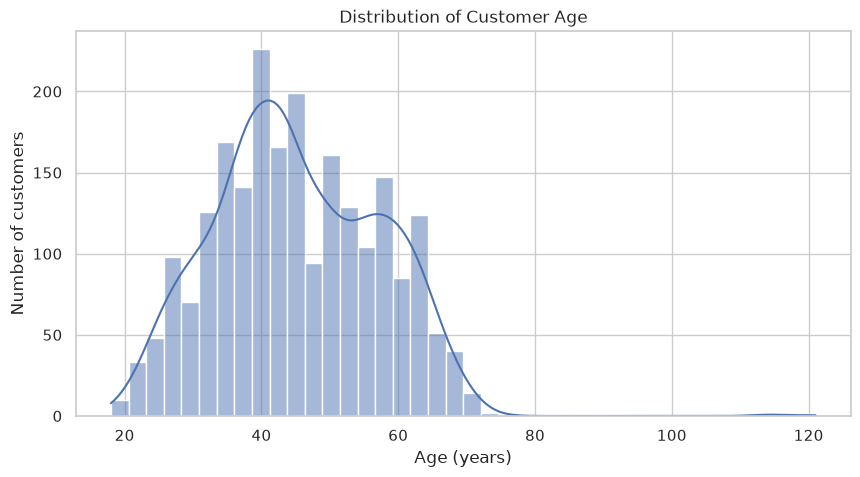

Customers older than 100: 3


In [6]:
#Plot a histogram that shows the distribution of ages
plt.figure(figsize=(10, 5))
sns.histplot(df['Age'], bins=40, kde=True)
plt.title('Distribution of Customer Age')
plt.xlabel('Age (years)')
plt.ylabel('Number of customers')
plt.show()

print('Customers older than 100:', (df['Age'] > 100).sum())


*What is your finding?* *Answer here*

**Answer:** Most customers are between about 35 and 55 years old (median 44, mean 45), so the customer base is mainly middle-aged adults. The distribution is fairly symmetric, with few customers under 25. Three customers have ages of 114, 115 and 121 (born 1893–1900). These are data-entry errors and are removed during cleaning below.

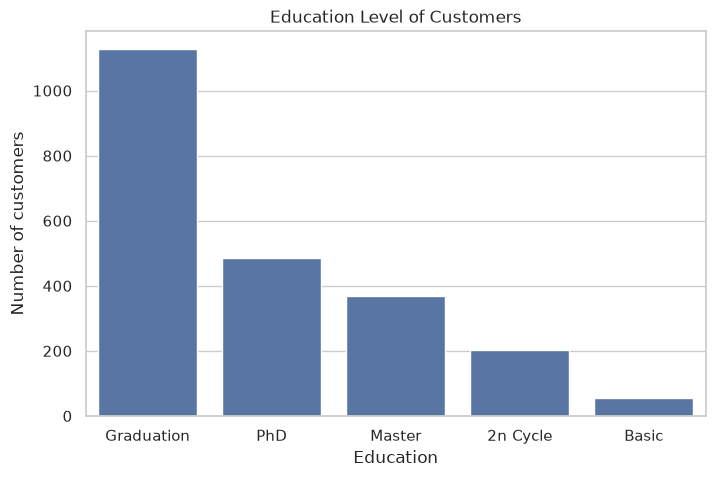

Education
Graduation    0.503
PhD           0.217
Master        0.165
2n Cycle      0.091
Basic         0.024
Name: proportion, dtype: float64

In [7]:
#Draw a plot diagram for the education level of customers
plt.figure(figsize=(8, 5))
order = df['Education'].value_counts().index
sns.countplot(data=df, x='Education', order=order)
plt.title('Education Level of Customers')
plt.ylabel('Number of customers')
plt.show()

df['Education'].value_counts(normalize=True).round(3)


*Please comment here*

**Comment:** The customer base is highly educated. About half (50%) have a Graduation (bachelor's) degree, 22% a PhD and 17% a Master's. Only 9% are in the 2n Cycle group and just 2% have Basic education, so the Basic group is too small to support strong conclusions.

In [8]:
#What about the maital status of your customers?
#Plot a bar graph to see the different distribution of customers
#Try using plotly here since it is more interactive 

# 'Alone' is the same as 'Single'; 'Absurd' and 'YOLO' are not real statuses
df['Marital_Status'] = df['Marital_Status'].replace({'Alone': 'Single', 'Absurd': 'Other', 'YOLO': 'Other'})

marital_counts = df['Marital_Status'].value_counts().reset_index()
marital_counts.columns = ['Marital_Status', 'Count']
fig = px.bar(marital_counts, x='Marital_Status', y='Count', text='Count',
             title='Marital Status of Customers')
fig.show()


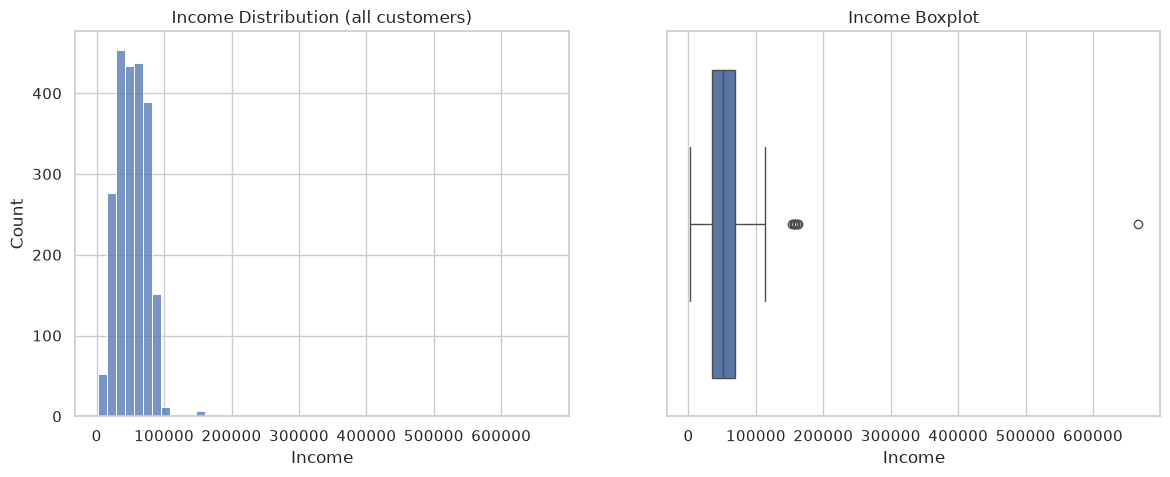

Missing Income values: 24
Skewness: 6.76


2233    666666.0
617     162397.0
687     160803.0
1300    157733.0
164     157243.0
1653    157146.0
2132    156924.0
655     153924.0
Name: Income, dtype: float64

In [9]:
#Income! A very important feature. 
#Plot a bar graph to show the distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Income'].dropna(), bins=50, ax=axes[0])
axes[0].set_title('Income Distribution (all customers)')
sns.boxplot(x=df['Income'], ax=axes[1])
axes[1].set_title('Income Boxplot')
plt.show()

print('Missing Income values:', df['Income'].isna().sum())
print('Skewness:', round(df['Income'].skew(), 2))
df['Income'].sort_values(ascending=False).head(8)


*Provide an analysis of the above findings*

**Analysis:** Most customers are married (864) or living together (580), so roughly 65% live in a couple. The rest are single (483), divorced (232) or widowed (77); the few nonsense entries ('Absurd', 'YOLO') were grouped as 'Other'. Income is centred around 51k (median) with most customers between 35k and 69k. The raw data is heavily right-skewed (skewness 6.8) because of an obvious outlier at 666,666 and a handful of incomes above 150k. Income also has 24 missing values that must be handled before modelling.

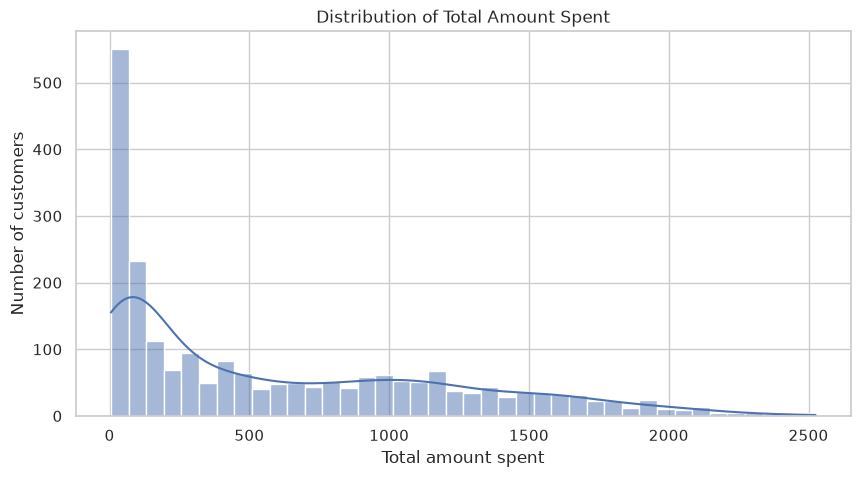

Skewness: 0.86


In [10]:
#What is the distribution for the TotalAmount Spent? 
#Do a histogram that shows this information
plt.figure(figsize=(10, 5))
sns.histplot(df['TotalAmountSpent'], bins=40, kde=True)
plt.title('Distribution of Total Amount Spent')
plt.xlabel('Total amount spent')
plt.ylabel('Number of customers')
plt.show()

print('Skewness:', round(df['TotalAmountSpent'].skew(), 2))


###Bivariate Analysis

Once you have completed the univariate analysis on all the features you're interested in, the subsequent step is to conduct bivariate analysis which involves examining two attributes simultaneously. Bivariate analysis involves assessing the relationship between two features, such as their correlation.
In our project, we will perform various bivariate analyses, such as examining the average total expenditure among different age groups of clients, establishing a correlation between customer income and total expenditure, and so forth.

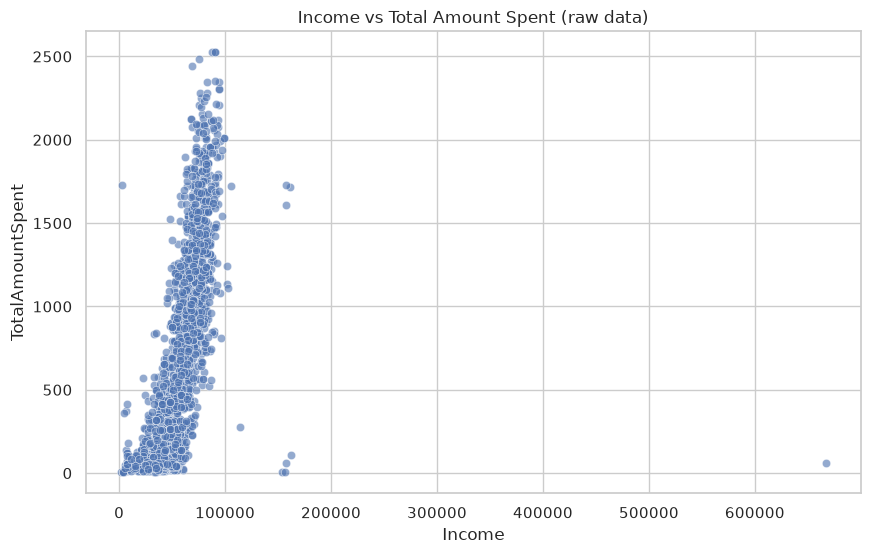

Rows removed: 8
Remaining rows: 2232


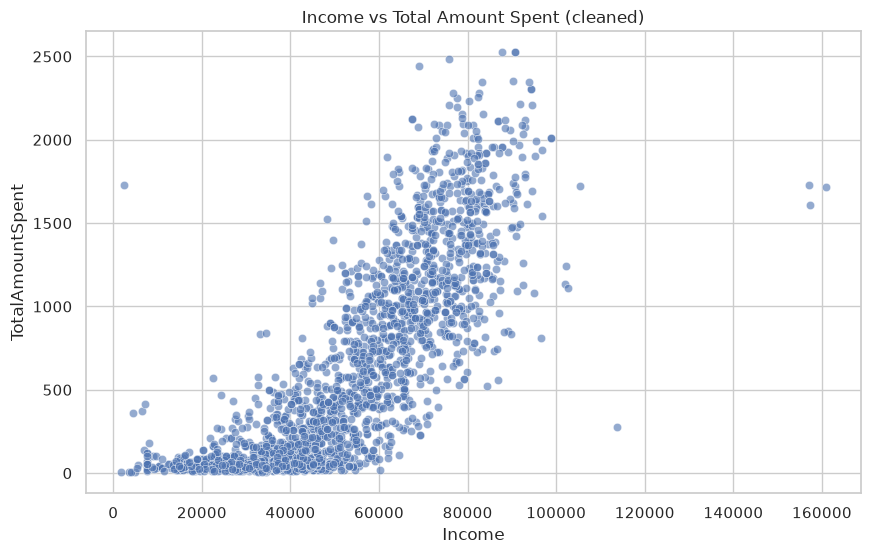

Correlation: 0.82


In [11]:
#Is there any relation between Customer's Income and TotalAmountSpent? 
# Draw a scatter plot to answer the above question
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Income', y='TotalAmountSpent', alpha=0.6)
plt.title('Income vs Total Amount Spent (raw data)')
plt.show()

# Cleaning revealed by the plots above:
# 1. Ages above 100 (born before 1900) are data-entry errors.
# 2. Customers with Income > 150,000 but spending < 200 (including the 666,666 entry)
#    do not follow the clear income/spending trend and are treated as invalid.
invalid = (df['Age'] > 100) | ((df['Income'] > 150000) & (df['TotalAmountSpent'] < 200))
print('Rows removed:', invalid.sum())
df = df[~invalid].reset_index(drop=True)
print('Remaining rows:', len(df))

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Income', y='TotalAmountSpent', alpha=0.6)
plt.title('Income vs Total Amount Spent (cleaned)')
plt.show()

print('Correlation:', round(df['Income'].corr(df['TotalAmountSpent']), 3))


Of course, you noticed from the above scatterplot that some cleaning is required. Please feel free to clean the data before continuing.  

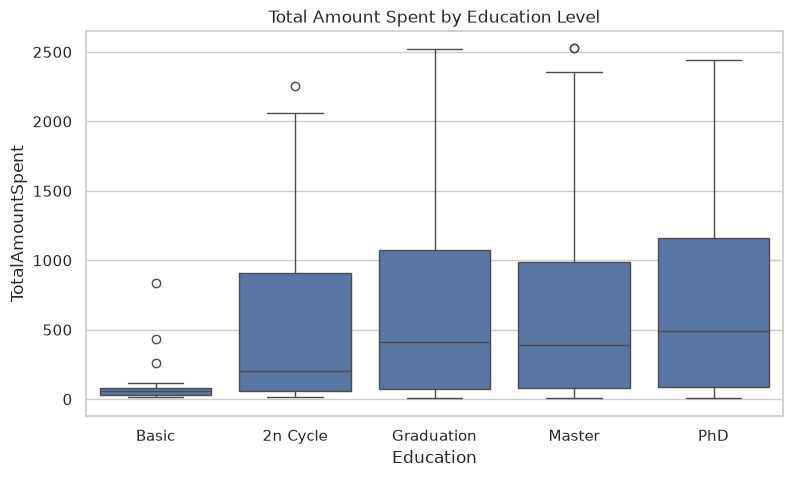

,median,mean,count
Education,,,
Basic,57.0,81.8,54
2n Cycle,205.0,501.0,201
Graduation,415.0,620.9,1125
Master,390.0,613.3,369
PhD,493.0,672.5,483


In [12]:
#What about the relation between Education and Total amount spent?
#Draw a suitable figure to answer the above question. 
order = ['Basic', '2n Cycle', 'Graduation', 'Master', 'PhD']
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='Education', y='TotalAmountSpent', order=order)
plt.title('Total Amount Spent by Education Level')
plt.show()

df.groupby('Education')['TotalAmountSpent'].agg(['median', 'mean', 'count']).loc[order].round(1)


*Analyze the above and give your reasoning*

**Analysis:** Spending generally rises with education. Median spend is only 57 for Basic and 205 for 2n Cycle, compared with 415 for Graduation, 390 for Master and 493 for PhD. This is most likely because education tracks income, which is strongly correlated with spending (r ≈ 0.82 after cleaning). Graduation, Master and PhD customers spend similar amounts and their boxes overlap a lot, so above the undergraduate level education on its own tells us little about spending.

###Multivariate Analysis

Multivariate Analysis consists of understanding the relationship between two or more variables.

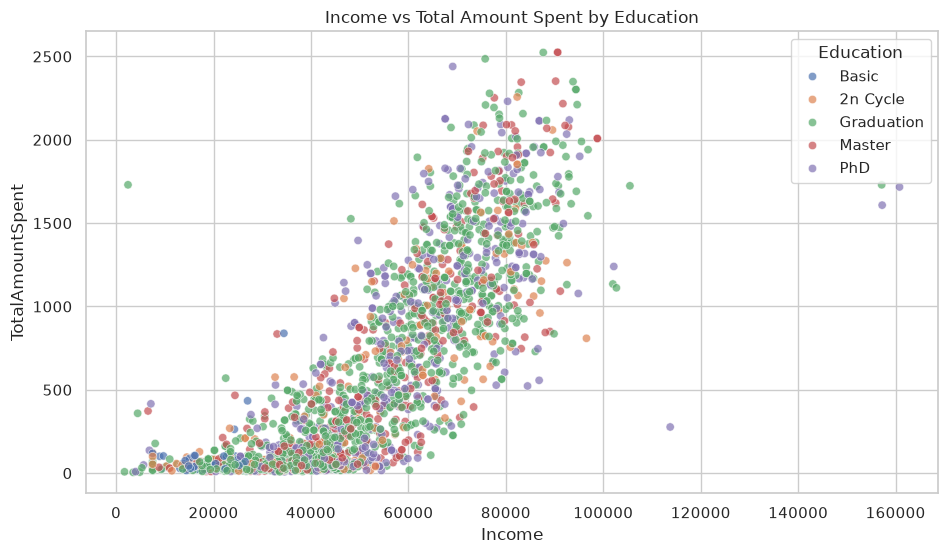

In [13]:
#Draw a scatter plot to check again the relation between income 
#on the x-axis and amount spent on th y-axis
#In addition, add the education feature as a color to differentiate 
#between the different points.
plt.figure(figsize=(11, 6))
sns.scatterplot(data=df, x='Income', y='TotalAmountSpent', hue='Education',
                hue_order=['Basic', '2n Cycle', 'Graduation', 'Master', 'PhD'], alpha=0.7)
plt.title('Income vs Total Amount Spent by Education')
plt.show()


#Clustering Time!

Once the analysis is complete, the subsequent step is to develop a model for segmenting the customers, using the KMeans model. KMeans is a widely used and effective segmentation model.
The KMeans model is an unsupervised machine learning algorithm that separates N observations into K clusters. The observations are grouped into these clusters based on their proximity to the centroid, which is the mean of that cluster.
By fitting the features into the model and specifying the desired number of clusters, the KMeans algorithm assigns a cluster label to each observation in the feature set.
When building a customer segmentation model using KMeans, there are no hard and fast rules for the number of features to include. However, it's advisable to use fewer features to enable easier interpretation and understanding of the segment outcomes.
In our case, we will initially construct the KMeans model with two features and then use three features in the final model. Before starting, it's important to consider the KMeans assumptions, which are:
* The features must be numerical.
* The features used in KMeans must follow a normal distribution because the algorithm calculates average distances, which can be affected by outliers. Skewed features must be transformed into a normal distribution using Numpy's logarithm transformation package, np.log().
* The features must be on the same scale. We will use the Scikit-learn StandardScaler() module to ensure that the features are normalized.

For our initial model, we will utilize the Income and TotalAmountSpent features.
Initially, we will fill the missing values in the Income feature with the median number before proceeding with the model.

In [14]:
#Fill in missing values of income with median
df['Income'] = df['Income'].fillna(df['Income'].median())
print('Missing Income values:', df['Income'].isna().sum())


Missing Income values: 0


In [15]:
#Assume you would like to work only with Income and TotalAmountSpent, 
#define a new dataframe with only Income and TotalAmountSpent
data = df[['Income', 'TotalAmountSpent']]
data.head()


,Income,TotalAmountSpent
0,58138.0,1617
1,46344.0,27
2,71613.0,776
3,26646.0,53
4,58293.0,422


After completing the filling of missing values, we will transform the features and store the output in a variable named data_log.

In [16]:
#Apply log transformation
data_log = np.log(data)
data_log.describe().round(2)


,Income,TotalAmountSpent
count,2232.00,2232.00
mean,10.75,5.62
std,0.50,1.48
min,7.46,1.61
25%,10.48,4.23
50%,10.85,5.98
75%,11.13,6.95
max,11.99,7.83


Then we will scale the result using Scikit-learn StandardScaler():

In [17]:
#Apply standard scaler
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_log)
pd.DataFrame(data_scaled, columns=data.columns).describe().round(2)


,Income,TotalAmountSpent
count,2232.00,2232.00
mean,-0.00,0.00
std,1.00,1.00
min,-6.62,-2.71
25%,-0.55,-0.93
50%,0.19,0.25
75%,0.76,0.90
max,2.48,1.50


After completing the initial task, we can proceed to construct the model, specifically the KMeans model, which entails two essential parameters. The first parameter, random_state, ensures reproducible results, while the second parameter, n_clusters, determines the number of segments or clusters that will be created from KMeans.

In a business environment, the desired number of clusters for customer segmentation may be predetermined. However, in the absence of such prior knowledge, different cluster numbers must be tested to discover the optimal one.

Since we are not operating in a business environment, we will experiment with various cluster numbers. To select the best cluster, we will employ the elbow method, which involves plotting the error for each cluster and identifying a point on the graph where an elbow forms. Consequently, the ideal cluster will be the one that generates this elbow.

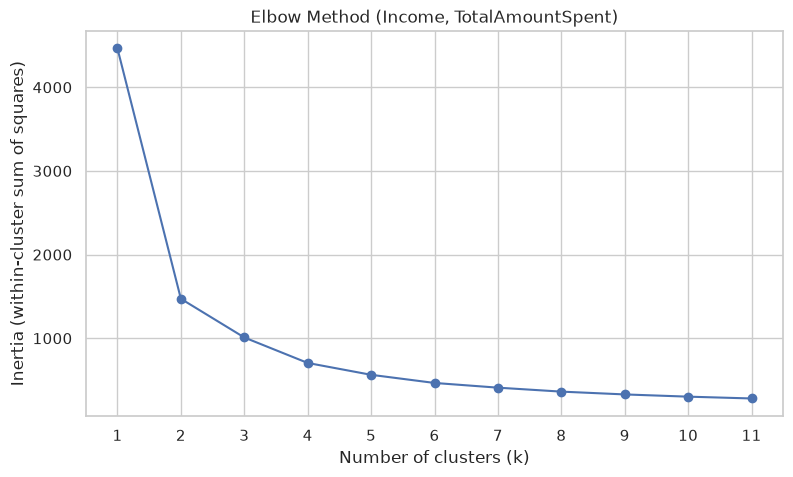

In [18]:
#Try value of k between 1 and 11 and plot the elbow method figure
errors = []
k_values = range(1, 12)
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(data_scaled)
    errors.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(list(k_values), errors, marker='o')
plt.title('Elbow Method (Income, TotalAmountSpent)')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.xticks(list(k_values))
plt.show()


In [19]:
#Now, build the KMeans model utilizing the best number of clusters.
# The elbow forms at k = 3: the drop in error flattens noticeably after it
model = KMeans(n_clusters=3, random_state=42, n_init=10)
model.fit(data_scaled)


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 2)","[[ 0.

After constructing the model, the subsequent step would involve interpreting the outcomes of each cluster. Various methods can be utilized to summarize the results of the clusters, depending on the desired objectives. The most prevalent method of summarization is the central tendency, which involves mean, median, and mode.

In our particular scenario, we will employ the median as our summarization method. This choice is due to the presence of outliers in the original features, which renders the mean overly sensitive to their influence. Consequently, we will aggregate the cluster labels and determine the median for Income and TotalAmountSpent. This can be accomplished using the Pandas groupby method.

Before using groupby and median, you have to assign the names of the columns to this new structure.

In [20]:
#use .assign(ClusterLabel = model.labels_)
clustered = data.assign(ClusterLabel=model.labels_)
clustered.head()


,Income,TotalAmountSpent,ClusterLabel
0,58138.0,1617,0
1,46344.0,27,2
2,71613.0,776,0
3,26646.0,53,1
4,58293.0,422,0


In [21]:
#Use groupby and median
summary = clustered.groupby('ClusterLabel').median()
summary['Count'] = clustered['ClusterLabel'].value_counts().sort_index()
summary


,Income,TotalAmountSpent,Count
ClusterLabel,,,
0,69016.0,1071.0,1075
1,25261.5,43.0,486
2,42586.0,145.0,671


*Analyze the clusters that you found in terms of median income and amount spent.*
Provide the best marketing strategy that you think will be successful for each cluster.


**Cluster analysis (median values; the label numbers can change if the notebook is re-run with a different library version):**

| Cluster | Median Income | Median Spent | Size | Profile |
|---|---|---|---|---|
| 0 | ~69,000 | ~1,071 | 1,075 | High income, high spend |
| 2 | ~42,600 | ~145 | 671 | Middle income, low–moderate spend |
| 1 | ~25,300 | ~43 | 486 | Low income, very low spend |

**Marketing strategies:**
- **High income / high spend (Cluster 0):** These are the most valuable customers, so focus on keeping them. Offer a loyalty or VIP programme, premium product lines, early access to new products and personalised recommendations. Discounts are not needed for this group.
- **Middle income / low spend (Cluster 2):** This group has the most room to grow. Use targeted promotions, bundles and cross-selling to raise basket size, and send reminders and recommendations to encourage more frequent purchases.
- **Low income / very low spend (Cluster 1):** This group is price-sensitive. Promote value products, discounts and coupons through low-cost channels (email, social media), and keep acquisition spending on this segment low.

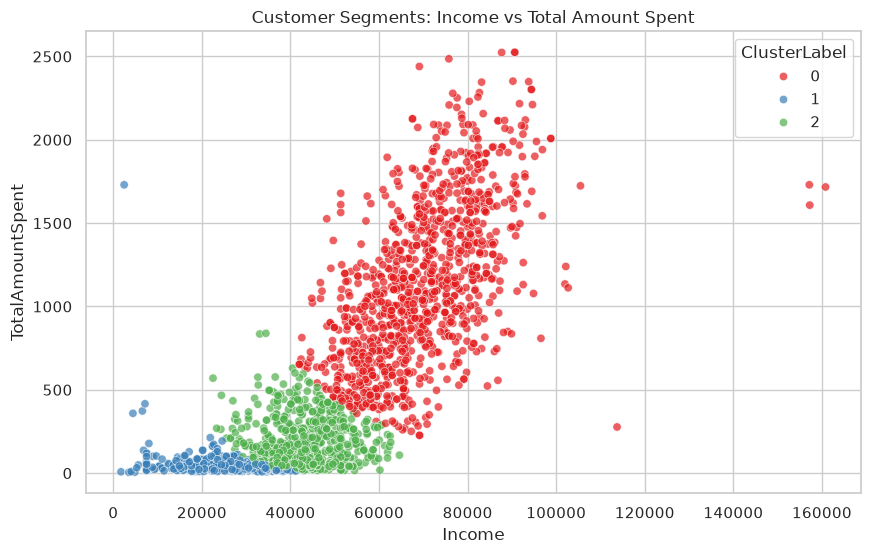

In [22]:
#Plot the clusters and differentiate each by a color
plt.figure(figsize=(10, 6))
sns.scatterplot(data=clustered, x='Income', y='TotalAmountSpent',
                hue='ClusterLabel', palette='Set1', alpha=0.7)
plt.title('Customer Segments: Income vs Total Amount Spent')
plt.show()


Repeat the above clustering while taking three features into consideration such as the age, income and amount spent. Interpret the clusters that you found and suggest marketing plans for each. 

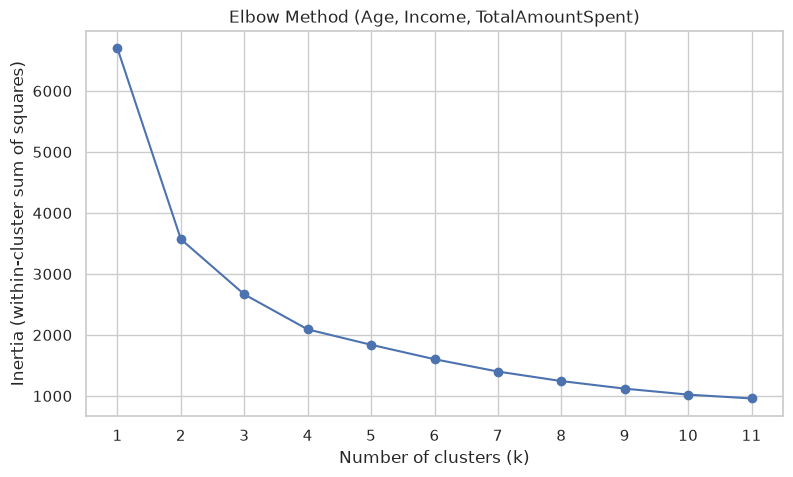

In [23]:
# Three features: Age, Income and TotalAmountSpent
data3 = df[['Age', 'Income', 'TotalAmountSpent']]

# Log transform and scale, as before
data3_log = np.log(data3)
data3_scaled = StandardScaler().fit_transform(data3_log)

errors3 = []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(data3_scaled)
    errors3.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(list(k_values), errors3, marker='o')
plt.title('Elbow Method (Age, Income, TotalAmountSpent)')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.xticks(list(k_values))
plt.show()


In [24]:
# The curve bends at k = 4; after that the error decreases only slowly
model3 = KMeans(n_clusters=4, random_state=42, n_init=10)
model3.fit(data3_scaled)

clustered3 = data3.assign(ClusterLabel=model3.labels_)
summary3 = clustered3.groupby('ClusterLabel').median()
summary3['Count'] = clustered3['ClusterLabel'].value_counts().sort_index()
summary3


,Age,Income,TotalAmountSpent,Count
ClusterLabel,,,,
0,37.0,67438.5,998.0,552
1,45.0,36778.0,61.0,609
2,56.0,64108.0,907.0,751
3,31.0,23966.5,54.5,320


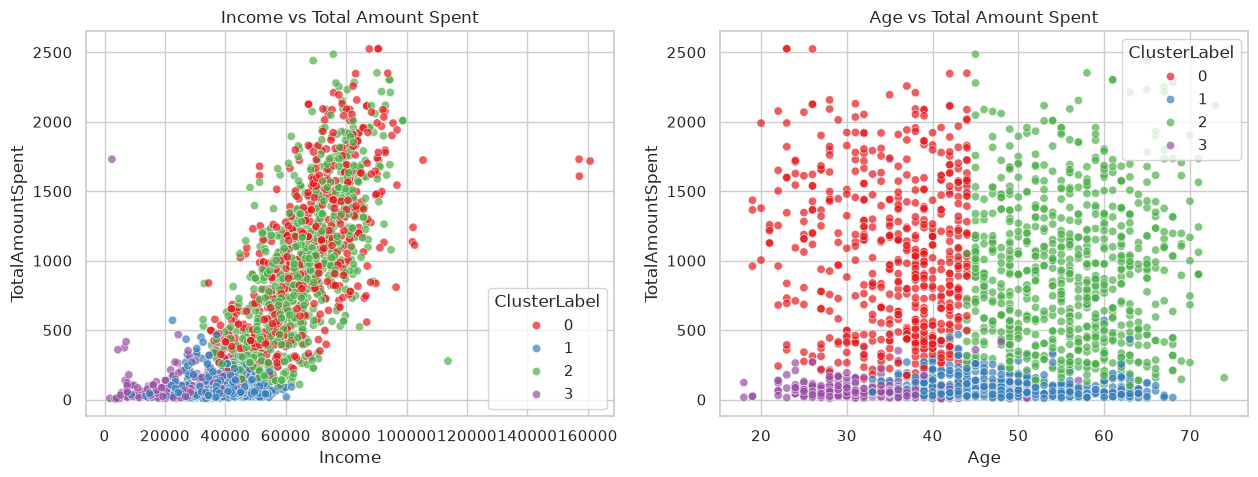

In [25]:
fig = px.scatter_3d(clustered3, x='Age', y='Income', z='TotalAmountSpent',
                    color=clustered3['ClusterLabel'].astype(str),
                    opacity=0.6, title='Customer Segments: Age, Income and Total Amount Spent',
                    labels={'color': 'ClusterLabel'})
fig.update_traces(marker=dict(size=3))
fig.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(data=clustered3, x='Income', y='TotalAmountSpent', hue='ClusterLabel',
                palette='Set1', alpha=0.7, ax=axes[0])
axes[0].set_title('Income vs Total Amount Spent')
sns.scatterplot(data=clustered3, x='Age', y='TotalAmountSpent', hue='ClusterLabel',
                palette='Set1', alpha=0.7, ax=axes[1])
axes[1].set_title('Age vs Total Amount Spent')
plt.show()


**Interpretation (median values; the label numbers can change if re-run):**

| Cluster | Median Age | Median Income | Median Spent | Size | Profile |
|---|---|---|---|---|---|
| 2 | 56 | ~64,100 | ~907 | 751 | Older, affluent, high spenders |
| 0 | 37 | ~67,400 | ~998 | 552 | Younger, affluent, high spenders |
| 1 | 45 | ~36,800 | ~61 | 609 | Middle-aged, lower income, low spenders |
| 3 | 31 | ~24,000 | ~55 | 320 | Young, low income, low spenders |

Adding age splits both the high-spending and the low-spending groups from the 2-feature model into a younger and an older segment. Income is still the main driver of spending, and age mainly changes *how* to reach each group.

**Marketing plans:**
- **Older affluent (Cluster 2):** Offer premium, quality-focused products and a loyalty programme with personal service. Use channels this group already trusts, such as email, catalogues and in-store events. Emphasise reliability and convenience (e.g. home delivery).
- **Younger affluent (Cluster 0):** Promote new, trendy and premium products through social media, mobile apps and influencers. Use limited editions, subscriptions and rewards to keep them engaged, and focus on growing their long-term value.
- **Middle-aged, lower income (Cluster 1):** These are likely family households on a budget. Offer family-size packs, bundles, discounts on everyday essentials and loyalty points to increase how often they buy.
- **Young, low income (Cluster 3):** Engage them with digital-first coupons, student or first-purchase discounts and entry-level products. Keep acquisition costs low, since their incomes, and possibly their spending, may grow over time.